<h1>Pneumonia detection using Convolutional neural networks</h1>

<h1>Objective :</h1>
<p>Pneumonia infection is a serious disease of the lungs with a range of possible causes. Bacteria, viruses or fungi can cause Pneumonia infection. Pneumonia is ranked as eighth leading for causing more no. of deaths in the US, It causes death in children younger than five years of age worldwide. To save precious lives many people humans and technology should interact.<p>

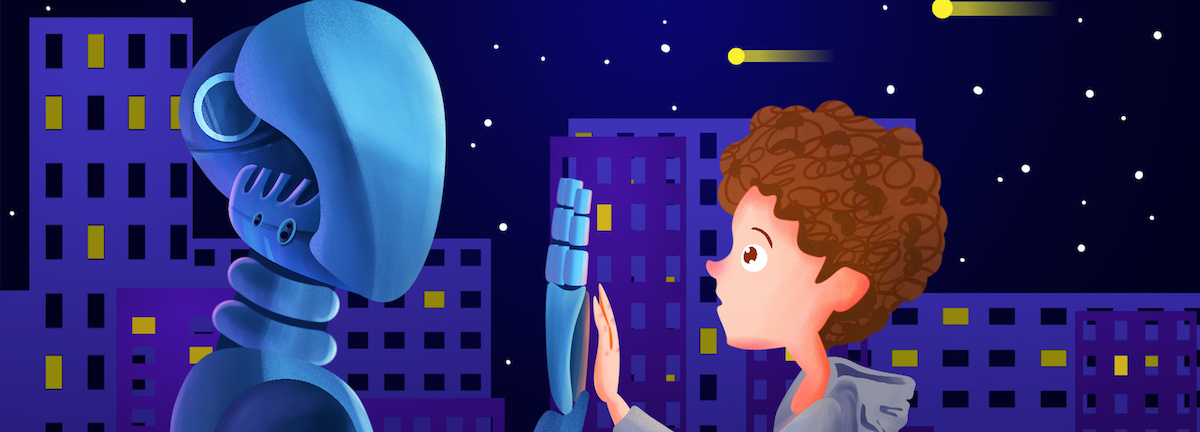


Chest X-rays are used for detecting the Pneumonia infection and to locate the infected area in the lungs.
So, To detect the the pneumonia radiologist have to observe the chest xray and he/she has to update the doctor correctly.
The main objective of this model is to identify if the person has Pneumonia or not with high accuracy so that the person can get treatment as soon as possible. Deep Learning models which are trained correctly by using good datasets can be helpful for doctors.
To train the model for detecting whether the person has pneumonia or not, A Convolutional Neural Network(CNN) is used. The CNN can train the images of chest xrays and then it can predict with high accuracy.



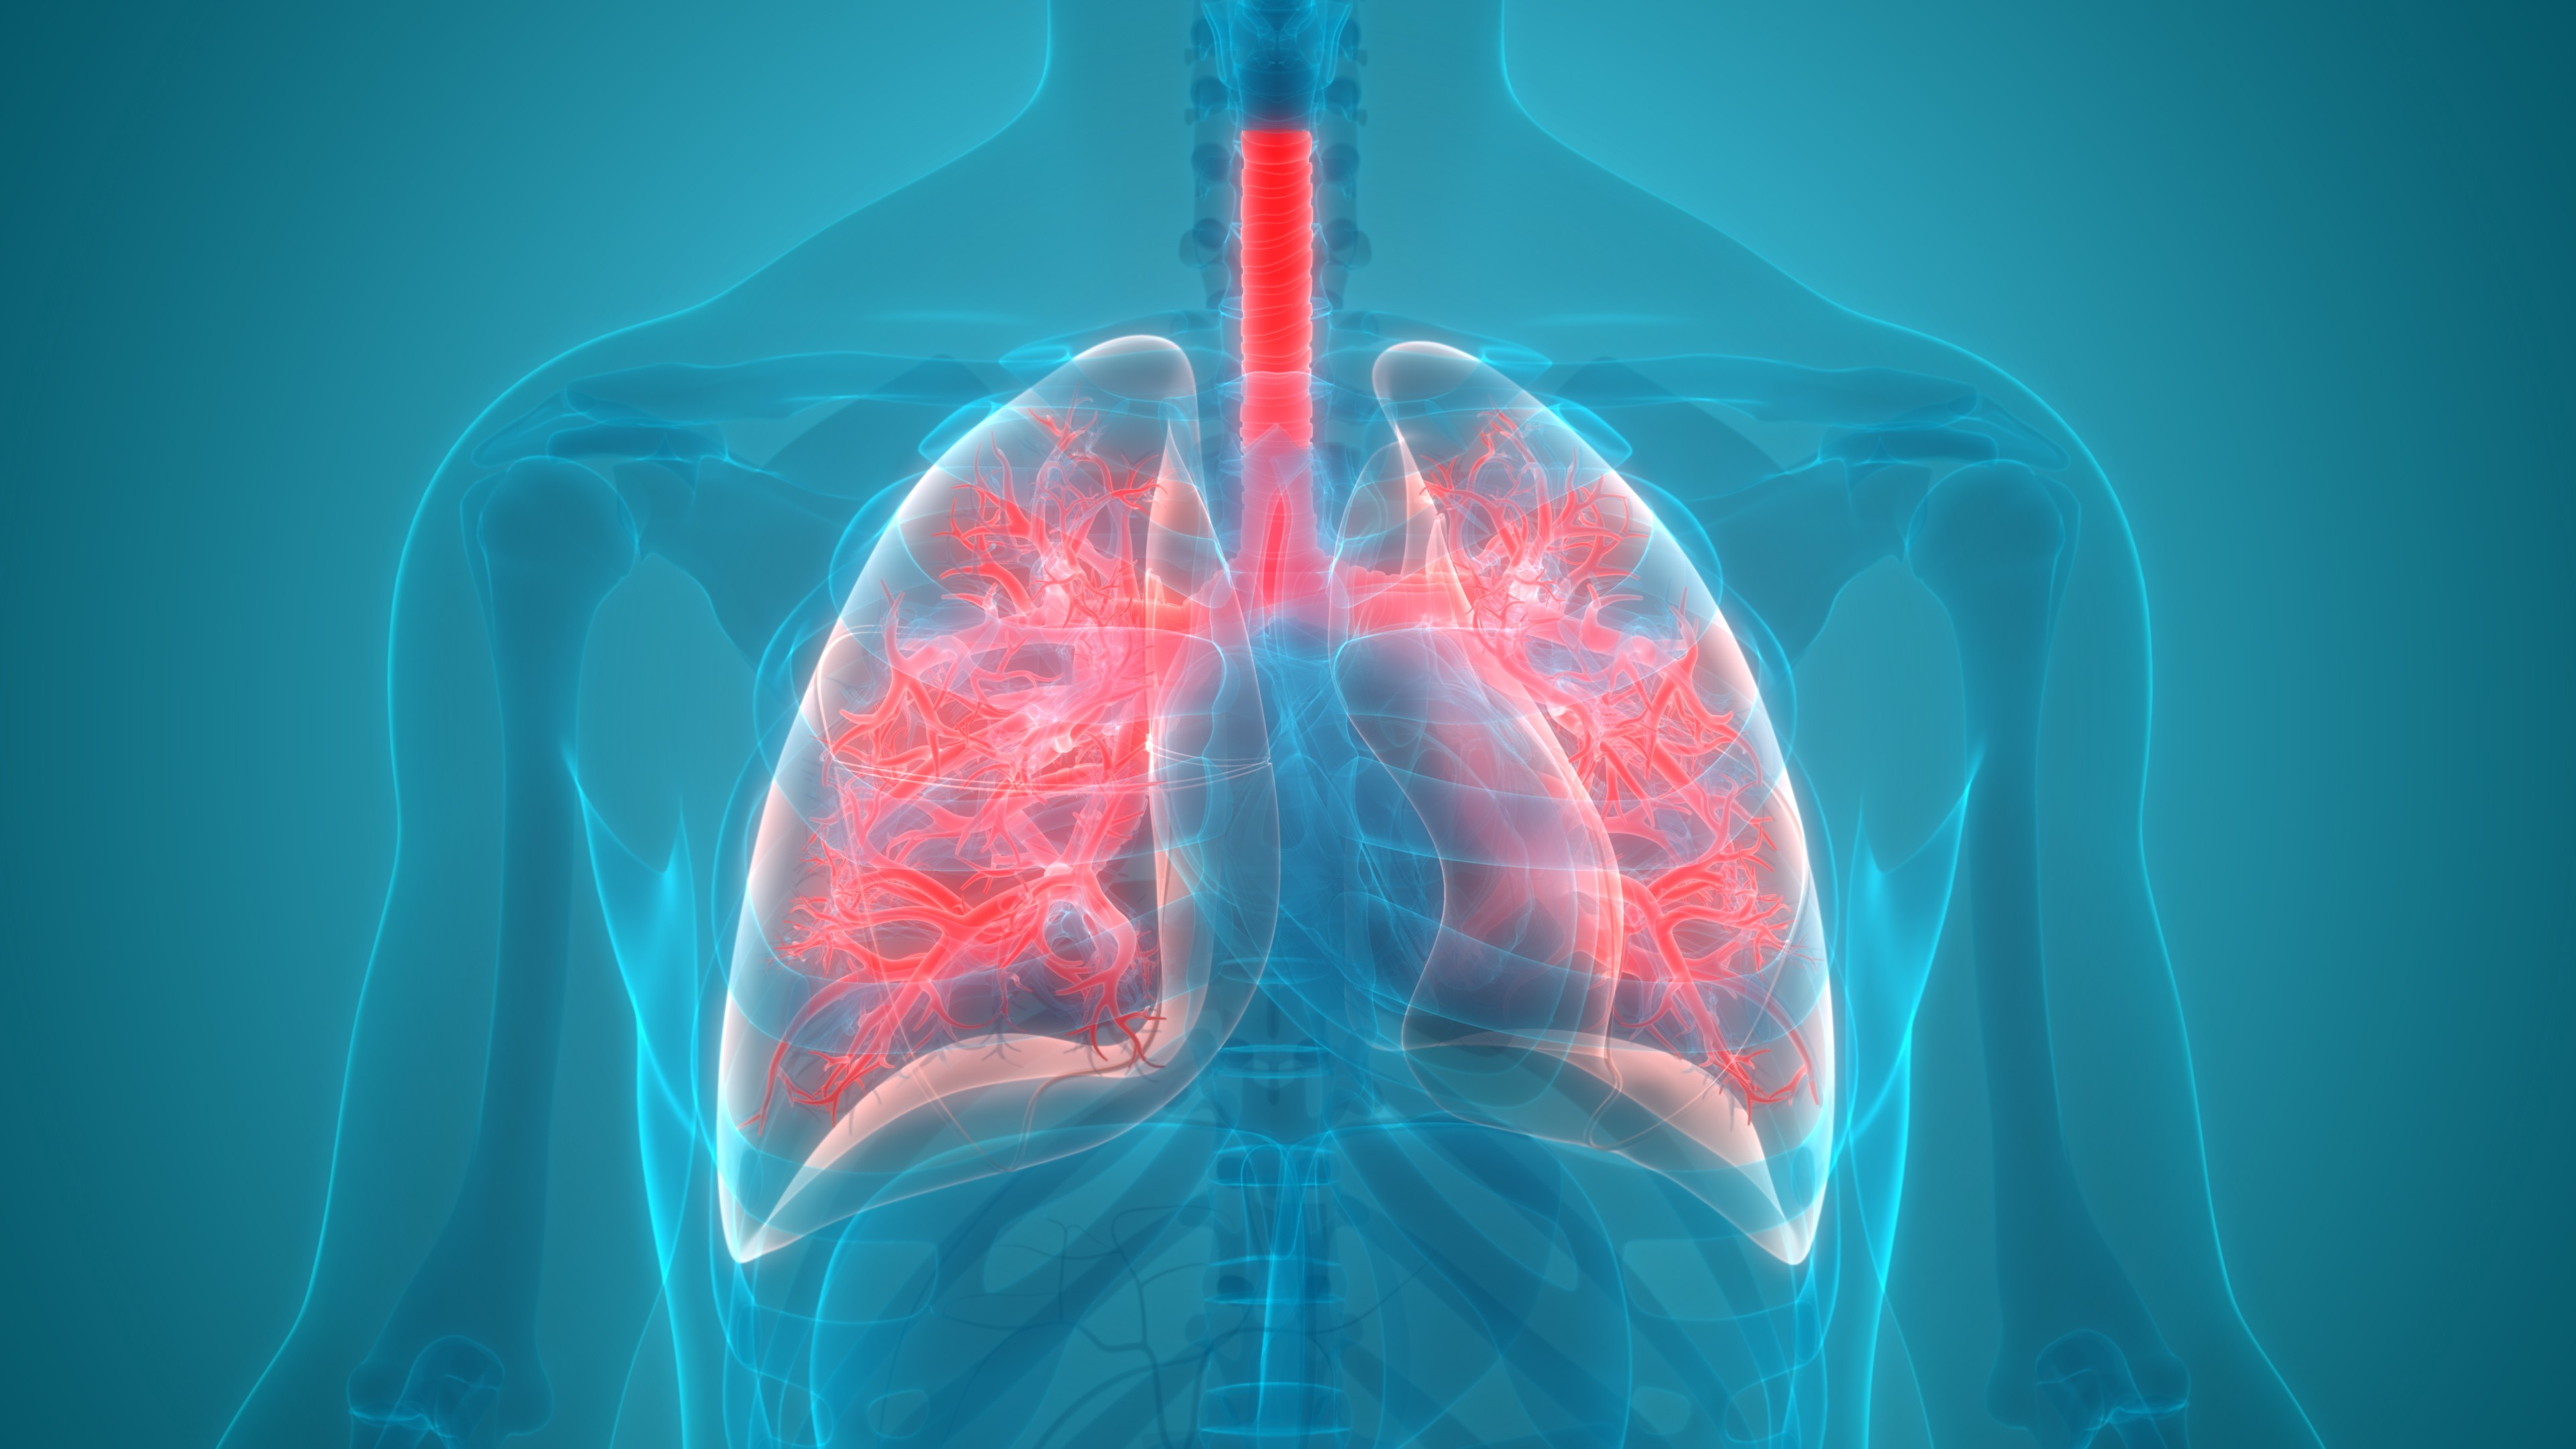

The dataset used here is chest xray dataset which is preprocessed.
You can find the **Dataset** [here.](https://www.kaggle.com/paultimothymooney/chest-xray-pneumonia)

The dataset consists of :


*   5216 training images of which 3815 are of Pneumonia and 1341 are normal images.
*   624 testing images of which 390 are of Pneumonia and 234 are normal.




**Libraries used :**

Numpy : Used for multidimensional arrays.

Matplotlib : Used to visualize data with graphs.

cv2 : OpenCV is used to deal with images.

Keras : It is the interface for Neural Networks and Tensorflow.

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from tensorflow.keras.optimizers import Adam

**Creating the train data generator.**

In [2]:
train_datagen = ImageDataGenerator(rescale = 1./255,
shear_range = 0.2,
zoom_range = 0.2,
horizontal_flip = True)


**Training data which is present in drive.**

In [3]:
train_images = "C:/Users/RAKESH/PycharmProjects/CCL_Project/chest_xray"

Here every image is resized to (300,300)

In [4]:
train_generator = train_datagen.flow_from_directory(train_images,
    target_size = (300,300),
    batch_size = 128,
    class_mode = 'binary')

Found 5856 images belonging to 3 classes.


**Model outputs :**

0 : Normal condition

1 : Pneumonia condition

In [5]:
train_generator.class_indices

{'test': 0, 'train': 1, 'val': 2}

**Validation data generator and loading validation data**

In [6]:
test_datagen = ImageDataGenerator(rescale = 1./255)
validation_generator = test_datagen.flow_from_directory("C:/Users/RAKESH/PycharmProjects/CCL_Project/chest_xray/val",
    target_size= (300,300),
    batch_size = 128,
    class_mode = 'binary')

Found 16 images belonging to 2 classes.


**Plotting :** Images with Pneumonia from dataset.

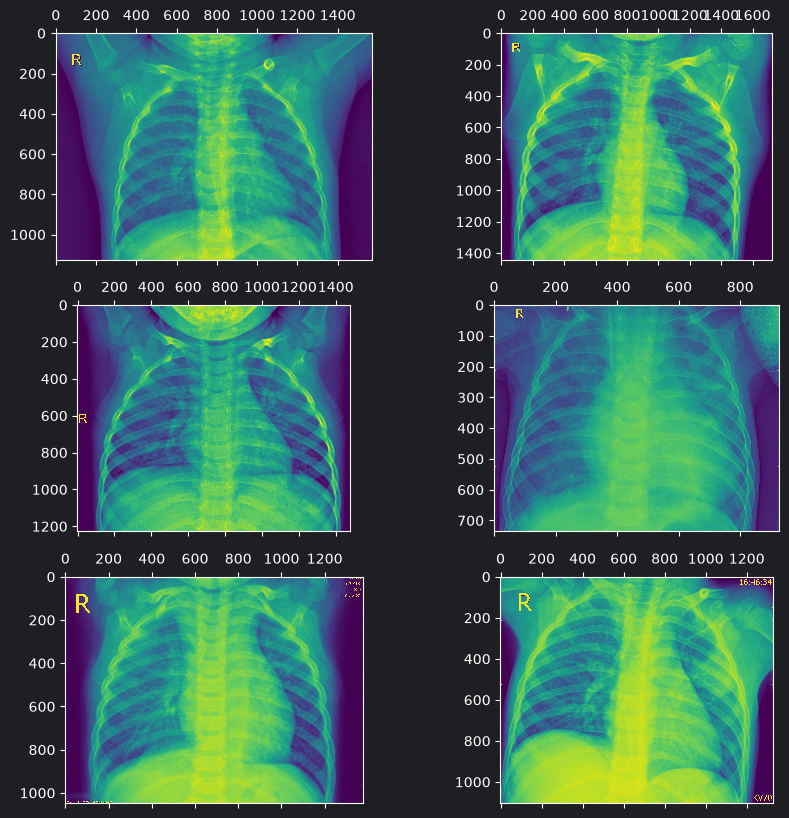

In [7]:
#Pneumonia
plot_image = plt.figure(figsize=(10,10))

plot1 = plot_image.add_subplot(3,2,1)
plot2 = plot_image.add_subplot(3,2,2)
plot3 = plot_image.add_subplot(3,2,3)
plot4 = plot_image.add_subplot(3,2,4)
plot5 = plot_image.add_subplot(3,2,5)
plot6 = plot_image.add_subplot(3,2,6)
plot1.matshow(plt.imread(train_generator.filepaths[41]))
plot2.matshow(plt.imread(train_generator.filepaths[176]))
plot3.matshow(plt.imread(train_generator.filepaths[1553]))
plot4.matshow(plt.imread(train_generator.filepaths[354]))
plot5.matshow(plt.imread(train_generator.filepaths[2679]))
plot6.matshow(plt.imread(train_generator.filepaths[2710]))

**Plotting :** Images without Pneumonia from dataset.

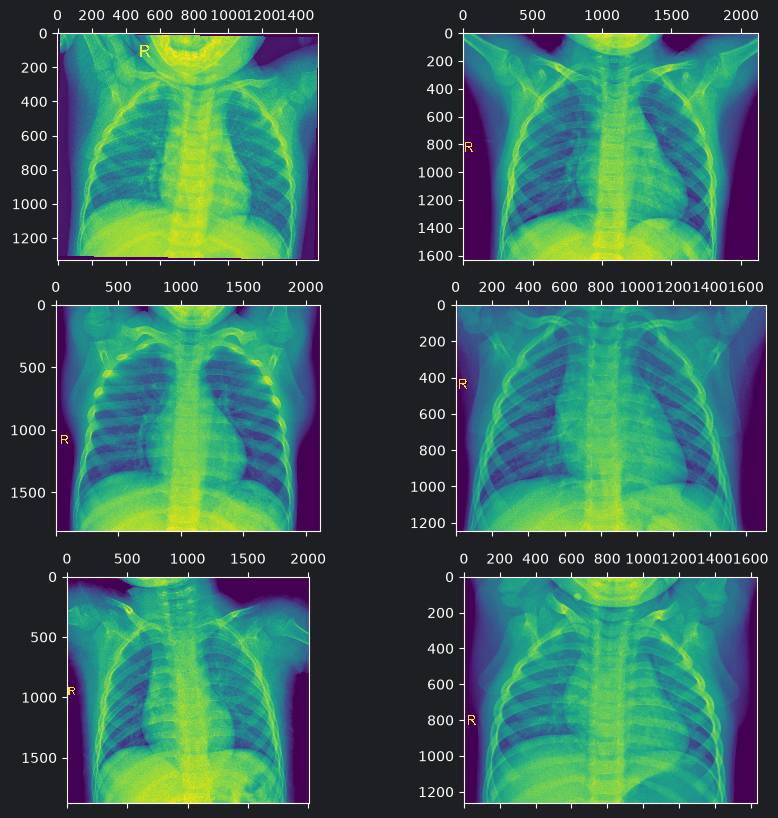

In [8]:
#Normal
plot_image = plt.figure(figsize=(10,10))

plot1 = plot_image.add_subplot(3,2,1)
plot2 = plot_image.add_subplot(3,2,2)
plot3 = plot_image.add_subplot(3,2,3)
plot4 = plot_image.add_subplot(3,2,4)
plot5 = plot_image.add_subplot(3,2,5)
plot6 = plot_image.add_subplot(3,2,6)
plot1.matshow(plt.imread(train_generator.filepaths[1419]))
plot2.matshow(plt.imread(train_generator.filepaths[1365]))
plot3.matshow(plt.imread(train_generator.filepaths[1400]))
plot4.matshow(plt.imread(train_generator.filepaths[1350]))
plot5.matshow(plt.imread(train_generator.filepaths[1345]))
plot6.matshow(plt.imread(train_generator.filepaths[1349]))

<h2><b> Convolutional Neural Network</b></h2>

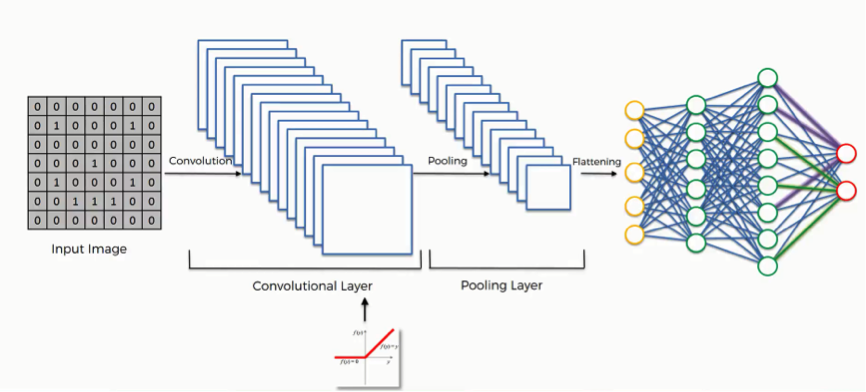

CNN consists of Convolutional layers, pooling layers.

ANN consists of hidden layers and output layers.

To develop the model I have used 5 Conv2D layers which are followed by maxpooling layers for every Conv2D layer.

Then for classification Artificial Neural Network with 2 hidden layers and one output layer which has a single neuron is used.




**Activation function :**

ReLU is used in the hidden layers and Conv2D layers.

Sigmoid is used because the output we need is of binary classification.

**Loss function :** Binary cross entropy is used.

**Optimizer :** Adam optimizer is used because it gives best result.

<h1>Neural Networks using TensorFlow</h1>

Metrics : Accuracy.

In [9]:
model= tf.keras.models.Sequential([
                                   tf.keras.layers.Conv2D(16, (3,3), activation= 'relu', input_shape= (300, 300, 3)),
                                   tf.keras.layers.MaxPool2D(2,2),
                                   tf.keras.layers.Conv2D(32, (3,3), activation= 'relu'),
                                   tf.keras.layers.MaxPool2D(2,2),
                                   tf.keras.layers.Conv2D(64, (3,3), activation= 'relu'),
                                   tf.keras.layers.MaxPool2D(2,2),
                                   tf.keras.layers.Conv2D(128, (3,3), activation= 'relu'),
                                   tf.keras.layers.MaxPool2D(2,2),
                                   tf.keras.layers.Conv2D(128, (3,3), activation= 'relu'),
                                   tf.keras.layers.MaxPool2D(2,2),

                                   tf.keras.layers.Flatten(),
                                   tf.keras.layers.Dense(256, activation= 'relu'),
                                   tf.keras.layers.Dense(512, activation= 'relu'),
                                   tf.keras.layers.Dense(1, activation= 'sigmoid')
])
model.summary()
model.compile(optimizer= 'adam', loss= 'binary_crossentropy', metrics= ['accuracy'])

C:\Users\RAKESH\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 298, 298, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 149, 149, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 147, 147, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 73, 73, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 71, 71, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 35, 35, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 33, 33, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,605,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,983,009 (7.56 MB)

 Trainable params: 1,983,009 (7.56 MB)

 Non-trainable params: 0 (0.00 B)

**Training the model for 50 epochs**

In [10]:
history = model.fit(train_generator, epochs = 50, validation_data = validation_generator)

Epoch 1/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 145s 3s/step - accuracy: 0.8730 - loss: 0.3850 - val_accuracy: 0.5000 - val_loss: 1.0389
Epoch 2/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 135s 3s/step - accuracy: 0.8907 - loss: 0.3413 - val_accuracy: 0.5000 - val_loss: 1.2282
Epoch 3/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 135s 3s/step - accuracy: 0.8907 - loss: 0.3378 - val_accuracy: 0.5000 - val_loss: 1.2824
Epoch 4/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 134s 3s/step - accuracy: 0.8907 - loss: 0.3365 - val_accuracy: 0.5000 - val_loss: 1.1090
Epoch 5/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 134s 3s/step - accuracy: 0.8907 - loss: 0.3378 - val_accuracy: 0.5000 - val_loss: 1.0116
Epoch 6/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 134s 3s/step - accuracy: 0.8907 - loss: 0.3347 - val_accuracy: 0.5000 - val_loss: 1.2462
Epoch 7/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 134s 3s/step - accuracy: 0.8907 - loss: 0.3352 - val_accuracy: 0.5000 - val_loss: 1.1232
Epoch 8/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 134s 3s/step - accuracy: 0.8907 - loss: 0.3332 - val_accuracy: 0.5000 - v

<h2>Accuracy : 98.16%</h2>

<h2>Val_accuracy : 100%</h2>

In [11]:
loss = history.history['loss']
val_loss = history.history['val_loss']

**<h3>Plotting Loss Vs Num. of Epochs</h3>**

Loss Vs Num. of Epochs
Training Loss : 0.0519 
Value loss : 0.0701


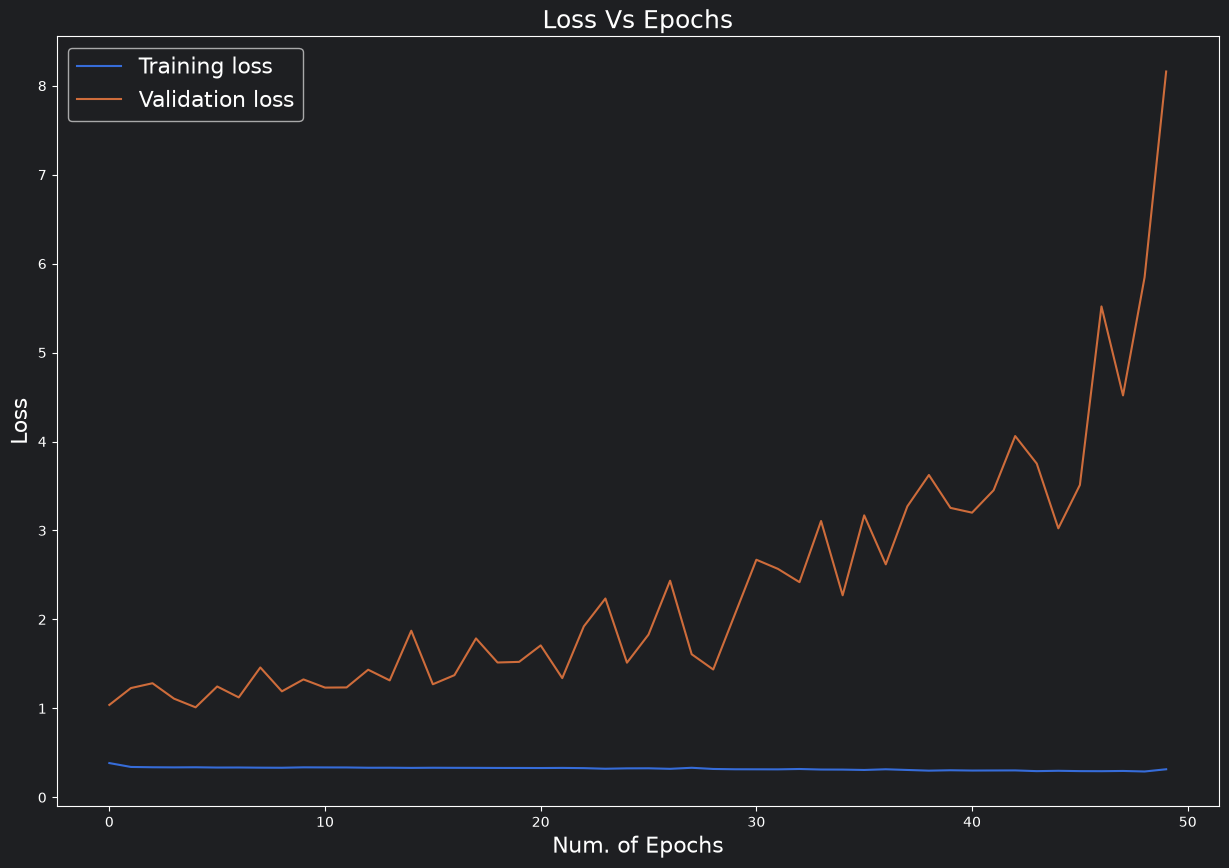

In [12]:
plt.figure(figsize=(15, 10))
plt.plot(loss)
plt.plot(val_loss)
plt.legend(['Training loss','Validation loss'], fontsize=16)
plt.title("Loss Vs Epochs", fontsize=18)
plt.xlabel("Num. of Epochs", fontsize=16)
plt.ylabel("Loss", fontsize=16)
print("Loss Vs Num. of Epochs")
print("Training Loss : 0.0519","\nValue loss : 0.0701")
plt.show()

In [13]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

**<h3>Plotting Accuracy Vs Num. of Epochs</h3>**

Accuracy Vs Epochs
Training accuracy : 0.9816 
Value accuracy : 1.0000


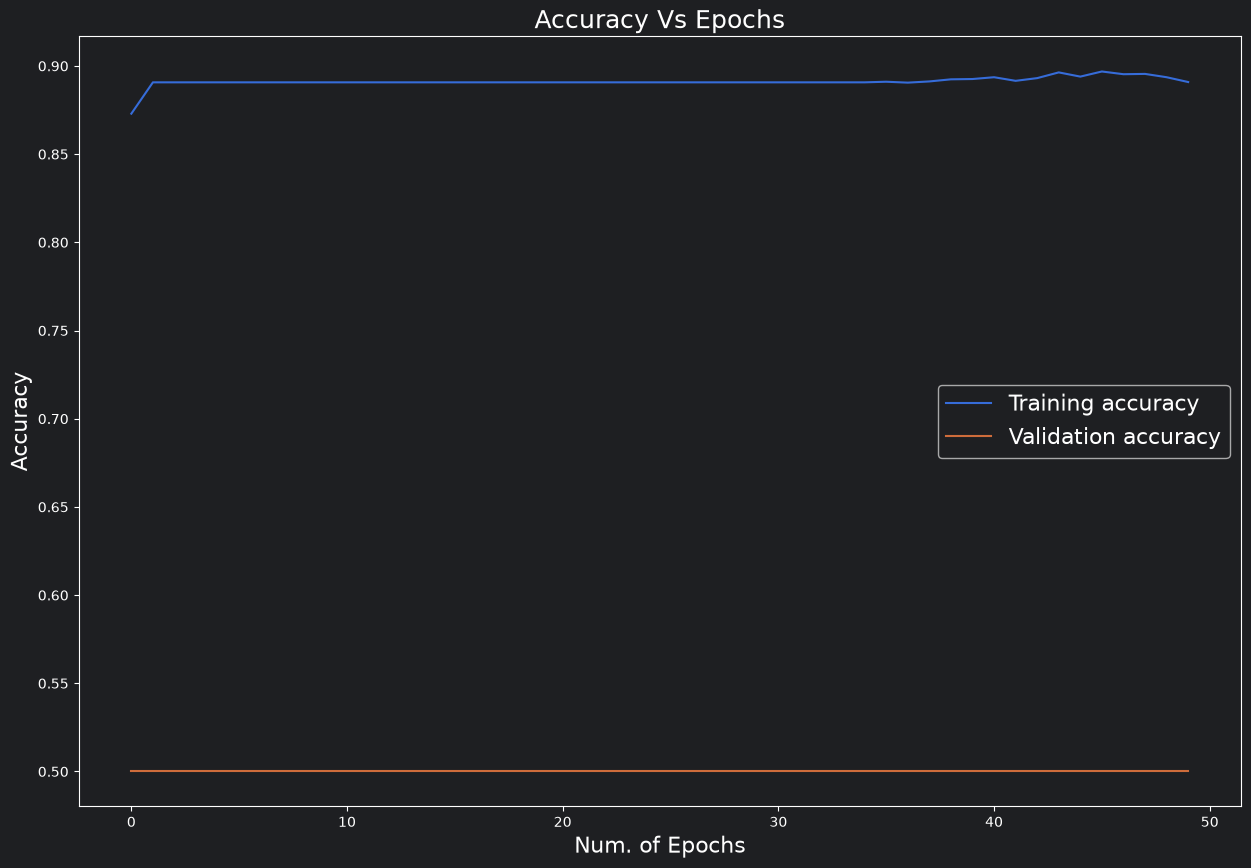

In [14]:
plt.figure(figsize=(15, 10))
plt.plot(acc)
plt.plot(val_acc)
plt.legend(['Training accuracy','Validation accuracy'], fontsize=16)
plt.title("Accuracy Vs Epochs", fontsize=18)
plt.xlabel("Num. of Epochs", fontsize=16)
plt.ylabel("Accuracy", fontsize=16)
print("Accuracy Vs Epochs")
print("Training accuracy : 0.9816","\nValue accuracy : 1.0000")
plt.show()

<h3>Saving the model</h3>

In [23]:
model.save("trained.h5")

<h3>Loading the saved model so that we can load the model which is already saved so lot of time can be saved and it can also be used for deployment.</h3>

In [24]:
from keras.models import load_model
model = load_model("trained.h5")

**Loading the test data generator**

In [28]:
eval_datagen = ImageDataGenerator(rescale=1/255)

test_generator = eval_datagen.flow_from_directory(
    "C:/Users/RAKESH/PycharmProjects/CCL_Project/chest_xray/test",
    target_size=(300, 300),
    batch_size=128,
    class_mode="binary",
    shuffle=False
)

eval_result = model.evaluate(test_generator)

print("Loss:", eval_result[0])
print("Accuracy:", eval_result[1])

Found 624 images belonging to 2 classes.
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 836ms/step - accuracy: 0.6250 - loss: 1.0653 
Loss: 1.0652650594711304
Accuracy: 0.625


The accuracy of test data is : <h3>92.1474%</h3>

**An image is used from drive for prediction**

In [37]:
import cv2
import numpy as np

img = cv2.imread(
    r"C:\Users\RAKESH\PycharmProjects\CCL_Project\chest_xray\test\NORMAL\IM-0017-0001.jpeg"
)

if img is None:
    print("Image not found!")
else:
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (300, 300))
    img = img / 255.0
    img = np.expand_dims(img, axis=0)

    prediction = model.predict(img)

    print("Prediction:", prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Prediction: [[0.7964183]]


The prediction shows value as **0.01** which is less than 0.5

so our model has to predict it as Normal which is done below.

Prediction: Pneumonia
Confidence: 79.64%


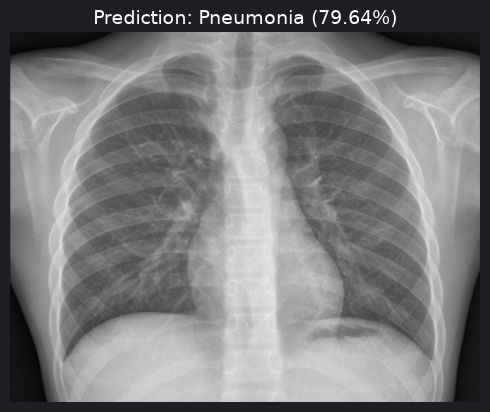

In [38]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_path = r"C:\Users\RAKESH\PycharmProjects\CCL_Project\chest_xray\test\NORMAL\IM-0017-0001.jpeg"

# Read image
img = cv2.imread(image_path)

if img is None:
    raise FileNotFoundError("Image could not be loaded.")

# Keep original image for displaying
tempimg = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Prepare image for model
img = cv2.resize(img, (300, 300))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = img / 255.0
img = np.expand_dims(img, axis=0)

# Prediction
prediction_prob = model.predict(img, verbose=0)[0][0]

if prediction_prob >= 0.5:
    prediction = "Pneumonia"
    confidence = prediction_prob * 100
else:
    prediction = "Normal"
    confidence = (1 - prediction_prob) * 100

print(f"Prediction: {prediction}")
print(f"Confidence: {confidence:.2f}%")

# Display image
plt.imshow(tempimg)
plt.title(
    f"Prediction: {prediction} ({confidence:.2f}%)",
    fontsize=14
)
plt.axis("off")
plt.show()

In [39]:
img= cv2.imread('C:/Users/RAKESH/PycharmProjects/CCL_Project/chest_xray/test/PNEUMONIA/person104_bacteria_492.jpeg')
tempimg = img
img = cv2.resize(img,(300,300))
img = img/255.0
img = img.reshape(1,300,300,3)
model.predict(img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


array([[0.88822037]], dtype=float32)

Here another image is used and the model predicted it as **0.999** which is greater than 0.5.

so it have be Pneumonia image which is predicted below.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Prediction: Pneumonia


Text(0.5, 1.0, 'Prediction: Pneumonia')

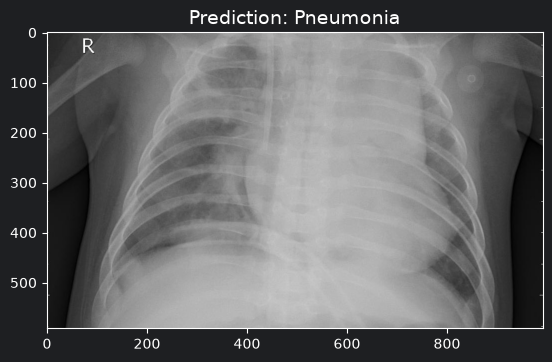

In [40]:
prediction = model.predict(img) >= 0.5
if prediction>=0.5:
  prediction = "Pneumonia"
else:
  prediction = "Normal"
print("Prediction: "+prediction)
plt.imshow(tempimg)
plt.title("Prediction: "+prediction, fontsize=14)

<h2>Conclusion :</h2>

This model can be used in Healthcare industry in the radiological department.

It can be deployed to Xray machines.

This can help radiologist to predict the chest xray images easily and accurately.
